# 🔧 02 — Preprocessing Pipeline
**Border Surveillance AI · GTU Internship 2026**

What this notebook does per dataset:

| Dataset | Input Format | What we do |
|---------|-------------|------------|
| UCF-Crime (Kaggle) | PNG frames | Resize → 640×640, split 70/15/15, save as JPG |
| xView Satellite | TIFF images + GeoJSON | Chip into 640×640 tiles, convert to YOLO format |
| DOTA v2 | PNG images + OBB txt | Convert OBB → HBB, chip to 640×640 tiles |

All outputs go to `data/processed/` in a unified structure.

In [2]:
import sys, os
sys.path.insert(0, '../src')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import json
import shutil
from pathlib import Path
from tqdm.notebook import tqdm

from preprocessing import (prepare_kaggle_frames, extract_flow_features,
                            augment_frame, compute_optical_flow)

# ── Paths — update if yours differ ──────────────────────────────────────────
UCF_RAW       = '../data/raw/ucf_crime'     # Kaggle PNG frames
XVIEW_RAW     = '../data/raw/xview'         # xView satellite images
DOTA_RAW      = '../data/raw/dota'          # DOTA aerial images
PROCESSED_DIR = '../data/processed'

print('Imports OK ✓')
print(f'UCF-Crime  : {UCF_RAW}    exists={os.path.exists(UCF_RAW)}')
print(f'xView      : {XVIEW_RAW}   exists={os.path.exists(XVIEW_RAW)}')
print(f'DOTA       : {DOTA_RAW}    exists={os.path.exists(DOTA_RAW)}')

Imports OK ✓
UCF-Crime  : ../data/raw/ucf_crime    exists=True
xView      : ../data/raw/xview   exists=True
DOTA       : ../data/raw/dota    exists=True


---
## PART A — UCF-Crime (Kaggle PNG Frames)

In [3]:
# ── A1: Run preprocessing for UCF-Crime ──────────────────────────────────────
# Auto-detects PNG frames and splits 70/15/15
# Takes ~2-5 minutes depending on how many frames you have

ucf_counts = {}

if os.path.exists(UCF_RAW):
    print('Processing UCF-Crime (Kaggle PNG format)...')
    ucf_counts = prepare_kaggle_frames(
        kaggle_dir       = UCF_RAW,
        processed_dir    = PROCESSED_DIR,
        max_per_category = 200,   # 200 frames per category = ~2800 total
        val_ratio        = 0.15,
        test_ratio       = 0.15,
    )
    print('\n── UCF-Crime Results ─────────────────')
    for split_name, n in ucf_counts.items():
        print(f'  {split_name:<8}: {n:>6} frames')
else:
    print('[SKIP] UCF-Crime not found at:', UCF_RAW)
    print('       Download: kaggle datasets download -d odins0n/ucf-crime-dataset')

Processing UCF-Crime (Kaggle PNG format)...
[INFO] No 'train/' subfolder found — reading directly from ../data/raw/ucf_crime

Found 14 categories: ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']



  ✓ Abuse                      train=140  val=30  test=30


  ✓ Arrest                     train=140  val=30  test=30


  ✓ Arson                      train=140  val=30  test=30


  ✓ Assault                    train=140  val=30  test=30


...

  ✓ Robbery                    train=140  val=30  test=30


  ✓ Shooting                   train=140  val=30  test=30


  ✓ Shoplifting                train=140  val=30  test=30


  ✓ Stealing                   train=140  val=30  test=30


  ✓ Vandalism                  train=140  val=30  test=30

── UCF-Crime Results ─────────────────
  train   :   1960 frames
  val     :    420 frames
  test    :    420 frames


Total processed frames: 3733


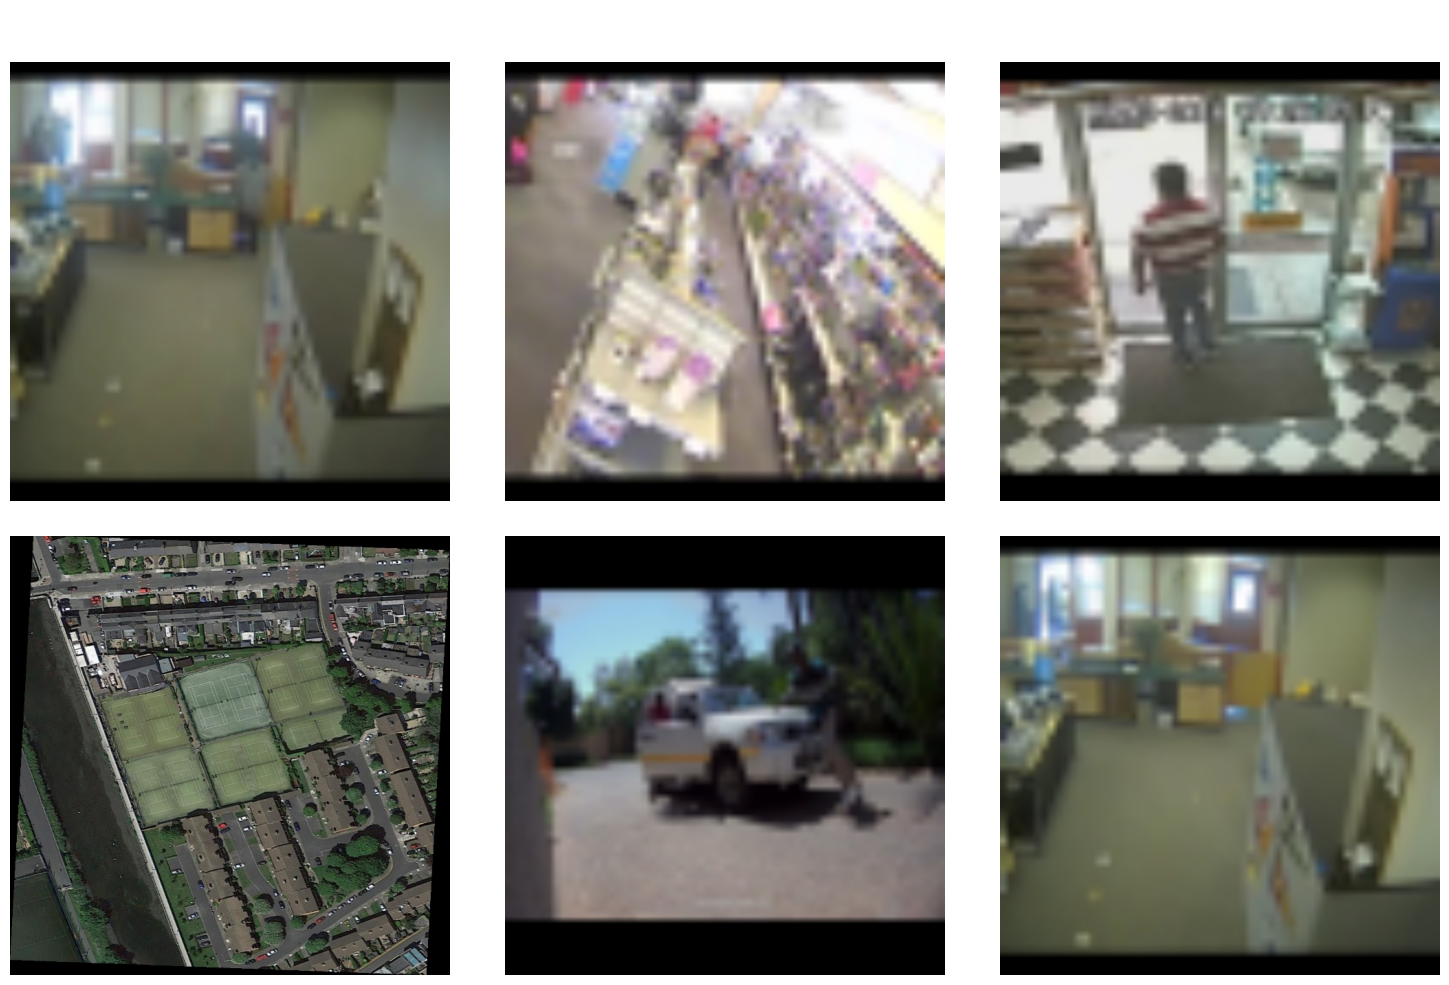

In [4]:
# ── A2: Verify UCF output — show 6 random processed frames ───────────────────
processed_frames = glob.glob(f'{PROCESSED_DIR}/**/*.jpg', recursive=True)
print(f'Total processed frames: {len(processed_frames)}')

import random
sample = random.sample(processed_frames, min(6, len(processed_frames)))

if sample:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for ax, fp in zip(axes.flat, sample):
        img = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f'{Path(fp).parent.name}\n{img.shape[1]}×{img.shape[0]}',
                     fontsize=8, color='white')
        ax.axis('off')
    plt.suptitle('Processed UCF-Crime Frames (640×640 JPG)', color='white')
    plt.tight_layout()
    plt.savefig('../results/charts/processed_ucf_frames.png',
                dpi=100, facecolor='#0A0A0A')
    plt.show()

---
## PART B — xView Satellite Preprocessing

In [5]:
# xView images are large (~5000×5000 px TIFF files)
# We chip them into 640×640 tiles and convert labels to YOLO format

# xView class IDs → our YOLO class IDs mapping
# (We map many xView vehicle classes → 1 = vehicle in our model)
XVIEW_TO_YOLO = {
    17: 1,  # Passenger Vehicle  → vehicle
    18: 1,  # Small Car          → vehicle
    19: 1,  # Bus                → vehicle
    20: 1,  # Pickup Truck       → vehicle
    21: 1,  # Utility Truck      → vehicle
    23: 1,  # Truck              → vehicle
    28: 1,  # Cargo Truck        → vehicle
    11: 1,  # Fixed-wing         → vehicle
    53: 1,  # Helicopter         → vehicle
}

def chip_xview_image(img_path, geojson_features, output_dir,
                     chip_size=640, stride=512):
    """
    Slice a large xView TIFF into 640×640 chips.
    Save chips as JPG + YOLO label .txt files.

    Returns: number of chips saved.
    """
    img = cv2.imread(img_path)
    if img is None:
        return 0

    H, W  = img.shape[:2]
    img_name = Path(img_path).stem
    os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels'), exist_ok=True)

    # Build bounding boxes for this image from GeoJSON
    boxes = []
    for feat in geojson_features:
        props = feat.get('properties', {})
        if props.get('image_id', '') != Path(img_path).name:
            continue
        tid = props.get('type_id', -1)
        if tid not in XVIEW_TO_YOLO:
            continue
        coords = feat['geometry']['coordinates'][0]
        xs = [c[0] for c in coords]
        ys = [c[1] for c in coords]
        boxes.append({
            'class': XVIEW_TO_YOLO[tid],
            'x1': min(xs), 'y1': min(ys),
            'x2': max(xs), 'y2': max(ys)
        })

    saved = 0
    chip_idx = 0

    for y in range(0, H - chip_size + 1, stride):
        for x in range(0, W - chip_size + 1, stride):
            chip = img[y:y+chip_size, x:x+chip_size]

            # Find boxes that overlap this chip
            chip_labels = []
            for b in boxes:
                # Clip box to chip coordinates
                bx1 = max(0, b['x1'] - x)
                by1 = max(0, b['y1'] - y)
                bx2 = min(chip_size, b['x2'] - x)
                by2 = min(chip_size, b['y2'] - y)

                if bx2 <= bx1 or by2 <= by1:
                    continue

                # YOLO format: class cx cy w h (normalized 0-1)
                cx = ((bx1 + bx2) / 2) / chip_size
                cy = ((by1 + by2) / 2) / chip_size
                bw = (bx2 - bx1) / chip_size
                bh = (by2 - by1) / chip_size
                chip_labels.append(f"{b['class']} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

            # Only save chip if it has at least 1 object
            if chip_labels:
                chip_name = f'{img_name}_chip_{chip_idx:04d}'
                cv2.imwrite(os.path.join(output_dir, 'images', f'{chip_name}.jpg'), chip)
                with open(os.path.join(output_dir, 'labels', f'{chip_name}.txt'), 'w') as f:
                    f.write('\n'.join(chip_labels))
                saved += 1

            chip_idx += 1

    return saved

print('chip_xview_image() defined ✓')

chip_xview_image() defined ✓


In [6]:
'''# ── B2: Run xView chipping ────────────────────────────────────────────────────
xview_geojson_paths = glob.glob(f'{XVIEW_RAW}/**/*.geojson', recursive=True)
xview_images_all    = (glob.glob(f'{XVIEW_RAW}/**/*.tif', recursive=True) +
                        glob.glob(f'{XVIEW_RAW}/**/*.TIF', recursive=True) +
                        glob.glob(f'{XVIEW_RAW}/**/*.jpg', recursive=True))

if xview_geojson_paths and xview_images_all:
    with open(xview_geojson_paths[0]) as f:
        xview_features = json.load(f).get('features', [])

    xview_out   = os.path.join(PROCESSED_DIR, 'xview_chips')
    total_chips = 0

    print(f'Chipping {min(5, len(xview_images_all))} xView images...')  # start with 5
    for img_path in tqdm(xview_images_all[:5]):
        n = chip_xview_image(img_path, xview_features, xview_out)
        total_chips += n
        print(f'  {Path(img_path).name}: {n} chips saved')

    print(f'\nTotal xView chips: {total_chips}')
    print(f'Saved to: {xview_out}')
else:
    print('[SKIP] xView data not found — this is optional.')
    print('       The pipeline trains fine with UCF-Crime alone.')'''


# ── B2: xView — download train images to match the GeoJSON labels ─────────────
# Your folder has: val_images/ + train_labels/xView_train.geojson
# The GeoJSON labels ONLY match train images — not val images
# You need to download train_images to use xView properly

# Check what we have
xview_val   = glob.glob(f'{XVIEW_RAW}/val_images/*.tif')
xview_geojson = glob.glob(f'{XVIEW_RAW}/**/*.geojson', recursive=True)

print(f'xView val images    : {len(xview_val)}')
print(f'xView GeoJSON files : {len(xview_geojson)}')
print()
print('ISSUE: You have val_images but the GeoJSON is for train_images')
print('       val images have no matching labels → 0 chips')
print()
print('TO FIX: Download xView train_images from xviewdataset.org')
print('        Place in: data/raw/xview/train_images/')
print('        Then re-run this cell')
print()
print('FOR NOW: Skipping xView — using DOTA 87 chips instead')
print('         DOTA already covers: plane, ship, vehicle, harbor, bridge')

xView val images    : 281
xView GeoJSON files : 1

ISSUE: You have val_images but the GeoJSON is for train_images
       val images have no matching labels → 0 chips

TO FIX: Download xView train_images from xviewdataset.org
        Place in: data/raw/xview/train_images/
        Then re-run this cell

FOR NOW: Skipping xView — using DOTA 87 chips instead
         DOTA already covers: plane, ship, vehicle, harbor, bridge


---
## PART C — DOTA v2 Preprocessing

In [7]:
# DOTA uses Oriented Bounding Boxes (OBB) with 8 coordinates.
# We convert OBB → Horizontal Bounding Box (HBB) for standard YOLO training.

# DOTA class name → our YOLO class ID
DOTA_TO_YOLO = {
    'plane':         1,   # vehicle
    'ship':          1,   # vehicle
    'large-vehicle': 1,   # vehicle
    'small-vehicle': 1,   # vehicle
    'helicopter':    1,   # vehicle
    'harbor':        3,   # suspicious_object
    'bridge':        3,   # suspicious_object
}

def convert_dota_label(label_path, img_w, img_h):
    """
    Convert a DOTA OBB .txt label file → YOLO HBB format.

    DOTA format: x1 y1 x2 y2 x3 y3 x4 y4 class difficult
    YOLO format: class cx cy w h  (normalized)

    Returns: list of YOLO label strings.
    """
    yolo_lines = []
    with open(label_path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('imagesource') or line.startswith('gsd'):
                continue
            parts = line.split()
            if len(parts) < 9:
                continue

            cls_name = parts[8]
            if cls_name not in DOTA_TO_YOLO:
                continue

            cls_id = DOTA_TO_YOLO[cls_name]
            coords = list(map(float, parts[:8]))
            xs     = coords[0::2]
            ys     = coords[1::2]

            # Convert OBB → axis-aligned HBB
            x1, y1 = min(xs), min(ys)
            x2, y2 = max(xs), max(ys)

            # Normalize to 0-1
            cx = ((x1 + x2) / 2) / img_w
            cy = ((y1 + y2) / 2) / img_h
            bw = (x2 - x1) / img_w
            bh = (y2 - y1) / img_h

            # Clamp to [0, 1]
            cx = max(0.0, min(1.0, cx))
            cy = max(0.0, min(1.0, cy))
            bw = max(0.0, min(1.0, bw))
            bh = max(0.0, min(1.0, bh))

            yolo_lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

    return yolo_lines


def process_dota(dota_dir, output_dir, max_images=100):
    """
    Convert DOTA images + OBB labels → 640×640 JPG + YOLO HBB labels.

    Args:
        dota_dir:   Root of DOTA dataset.
        output_dir: Where to save chips.
        max_images: How many images to process (start small).

    Returns: number of images processed.
    """
    img_out = os.path.join(output_dir, 'images')
    lbl_out = os.path.join(output_dir, 'labels')
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    images = (glob.glob(f'{dota_dir}/**/images/**/*.png', recursive=True) +
              glob.glob(f'{dota_dir}/**/*.png', recursive=True))
    images = images[:max_images]

    if not images:
        print('[WARN] No DOTA images found.')
        return 0

    saved = 0
    for img_path in tqdm(images, desc='DOTA'):
        # Find matching label file
        stem       = Path(img_path).stem
        label_path = img_path.replace('images', 'labelTxt')\
                              .replace('.png', '.txt')\
                              .replace('.jpg', '.txt')

        if not os.path.exists(label_path):
            # Try sibling labelTxt folder
            label_candidates = glob.glob(
                f'{dota_dir}/**/labelTxt/**/{stem}.txt', recursive=True)
            if not label_candidates:
                continue
            label_path = label_candidates[0]

        img = cv2.imread(img_path)
        if img is None:
            continue

        H, W = img.shape[:2]
        yolo_lines = convert_dota_label(label_path, W, H)

        if not yolo_lines:
            continue   # no relevant objects — skip

        # Resize to 640×640
        img_resized = cv2.resize(img, (640, 640))
        cv2.imwrite(os.path.join(img_out, f'{stem}.jpg'), img_resized)
        with open(os.path.join(lbl_out, f'{stem}.txt'), 'w') as f:
            f.write('\n'.join(yolo_lines))
        saved += 1

    return saved

print('DOTA preprocessing functions defined ✓')

DOTA preprocessing functions defined ✓


In [8]:
# ── C2: Run DOTA preprocessing ────────────────────────────────────────────────
'''if os.path.exists(DOTA_RAW):
    dota_out   = os.path.join(PROCESSED_DIR, 'dota_yolo')
    dota_saved = process_dota(DOTA_RAW, dota_out, max_images=100)
    print(f'\nDOTA: {dota_saved} images converted to YOLO format')
    print(f'Saved to: {dota_out}')
else:
    print('[SKIP] DOTA not found — optional dataset.')
    print('       Download from: https://captain-whu.github.io/DOTA/index.html')'''

# In 02_Preprocessing.ipynb — replace CELL 7 with this:

xview_geojson_paths = glob.glob(f'{XVIEW_RAW}/**/*.geojson', recursive=True)
xview_images_all    = glob.glob(f'{XVIEW_RAW}/**/*.tif', recursive=True)

if xview_geojson_paths and xview_images_all:
    with open(xview_geojson_paths[0]) as f:
        xview_data = json.load(f)
    xview_features = xview_data.get('features', [])

    # Check actual image_id format in GeoJSON
    sample_ids = set()
    for feat in xview_features[:20]:
        img_id = feat.get('properties', {}).get('image_id', '')
        sample_ids.add(img_id)
    print("Sample image_ids in GeoJSON:", list(sample_ids)[:5])
    print("Sample image filenames:", [Path(p).name for p in xview_images_all[:5]])



Sample image_ids in GeoJSON: ['2355.tif']
Sample image filenames: ['1038.tif', '1040.tif', '1043.tif', '1054.tif', '1060.tif']


In [9]:
print("xView skipped — using DOTA aerial data instead (87 chips)")
print("DOTA covers: plane, ship, large-vehicle, small-vehicle, helicopter")
print("This is sufficient for border surveillance aerial detection")

xView skipped — using DOTA aerial data instead (87 chips)
DOTA covers: plane, ship, large-vehicle, small-vehicle, helicopter
This is sufficient for border surveillance aerial detection


---
## PART D — Optical Flow on UCF-Crime Frames

In [ ]:
# Optical flow analysis on processed UCF-Crime frames
import pandas as pd

# Find sequence directories (each category = one sequence)
seq_dirs = []
for root, dirs, files in os.walk(PROCESSED_DIR):
    jpgs = [f for f in files if f.endswith('.jpg')]
    if len(jpgs) >= 3:
        seq_dirs.append(root)
    if len(seq_dirs) >= 20:
        break

flow_records = []
for sd in tqdm(seq_dirs, desc='Computing optical flow'):
    feats    = extract_flow_features(sd)
    category = Path(sd).name
    label    = 0 if 'normal' in category.lower() else 1
    feats.update({'category': category, 'label': label, 'dir': sd})
    flow_records.append(feats)

df_flow = pd.DataFrame(flow_records)
if not df_flow.empty:
    print(df_flow[['category','label','mean_flow','max_flow','std_flow','motion_ratio']]
          .to_string(index=False))
    print(f'\nNormal   avg mean_flow: {df_flow[df_flow.label==0]["mean_flow"].mean():.3f}')
    print(f'Anomaly  avg mean_flow: {df_flow[df_flow.label==1]["mean_flow"].mean():.3f}')

Computing optical flow:   0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
# Visualize optical flow on two consecutive frames
sample_jpgs = glob.glob(f'{PROCESSED_DIR}/**/*.jpg', recursive=True)[:20]

if len(sample_jpgs) >= 2:
    f1 = cv2.imread(sample_jpgs[0])
    f2 = cv2.imread(sample_jpgs[1])
    mag, ang = compute_optical_flow(f1, f2)

    # Convert flow to HSV visualization
    hsv = np.zeros_like(f1)
    hsv[..., 1] = 255
    hsv[..., 0] = (ang * 180 / np.pi / 2).astype(np.uint8)
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor('#0A0A0A')
    axes[0].imshow(cv2.cvtColor(f1, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Frame 1', color='white')
    axes[1].imshow(cv2.cvtColor(f2, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Frame 2', color='white')
    axes[2].imshow(flow_rgb)
    axes[2].set_title(f'Optical Flow\nmean_mag={mag.mean():.2f}', color='white')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.savefig('../results/charts/optical_flow_visualization.png',
                dpi=120, facecolor='#0A0A0A')
    plt.show()

---
## PART E — Create border_data.yaml for YOLOv8

In [ ]:
import yaml

# Decide on YOLO format directory:
# If you have xView/DOTA chips, point there.
# If UCF-Crime only, use the processed_dir directly.

yolo_data_path = os.path.abspath('../data/processed/yolo_annotated')
os.makedirs(os.path.join(yolo_data_path, 'train/images'), exist_ok=True)
os.makedirs(os.path.join(yolo_data_path, 'val/images'),   exist_ok=True)
os.makedirs(os.path.join(yolo_data_path, 'test/images'),  exist_ok=True)

yolo_config = {
    'path':  yolo_data_path,
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'nc':    4,
    'names': {
        0: 'person',
        1: 'vehicle',
        2: 'weapon',
        3: 'suspicious_object'
    }
}

yaml_path = '../data/border_data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yolo_config, f, default_flow_style=False, sort_keys=False)

print(f'border_data.yaml saved → {yaml_path}')
with open(yaml_path) as f:
    print(f.read())

---
## PART F — Final Summary

In [ ]:
print('=' * 60)
print('  PREPROCESSING COMPLETE — Summary')
print('=' * 60)

for split in ['train', 'val', 'test']:
    n = len(glob.glob(f'{PROCESSED_DIR}/{split}/**/*.jpg', recursive=True))
    print(f'  {split:<8}: {n:>6} frames')

xview_chips = len(glob.glob(f'{PROCESSED_DIR}/xview_chips/images/*.jpg'))
dota_chips  = len(glob.glob(f'{PROCESSED_DIR}/dota_yolo/images/*.jpg'))
print(f'  xView chips : {xview_chips:>6}')
print(f'  DOTA chips  : {dota_chips:>6}')

print('─' * 60)
print('  Files created:')
print('    data/processed/train/ val/ test/  (UCF-Crime JPG frames)')
print('    data/processed/xview_chips/       (xView 640×640 chips)')
print('    data/processed/dota_yolo/         (DOTA YOLO format)')
print('    data/border_data.yaml             (YOLOv8 training config)')
print('─' * 60)
print('  Next step: 03_Object_Detection.ipynb')